# Import Libraries and Load Dataset

In [1]:
import pandas as pd

path = r"C:\Users\Divyesh\.cache\kagglehub\datasets\bhavikjikadara\car-price-prediction-dataset\versions\1\car_prediction_data.csv"

df = pd.read_csv(path)

# Task 1 : Load the Dataset

In [2]:
# Import Required Library
import pandas as pd

# Load Dataset
path = r"C:\Users\Divyesh\.cache\kagglehub\datasets\bhavikjikadara\car-price-prediction-dataset\versions\1\car_prediction_data.csv"

df = pd.read_csv(path)

# Display First 5 Rows
print("========== First 5 Rows ==========")
print(df.head())

# Display Last 5 Rows
print("\n========== Last 5 Rows ==========")
print(df.tail())

# Display Shape
print("\n========== Shape of Dataset ==========")
print(df.shape)

# Display Column Names
print("\n========== Column Names ==========")
print(df.columns)

# Display Data Types
print("\n========== Data Types ==========")
print(df.dtypes)

========== First 5 Rows ==========
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  

========== Last 5 Rows ==========
    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
296     city  2016           9.50           11.6       33988    Diesel   
297     brio  2015           4.00            5.9       60000    Petrol   
298     city  2009           3.35           11.0       8793

# Task 2 : Explore the Dataset

In [3]:
# Display Dataset Information
print("========== Dataset Information ==========")
df.info()

# Display Statistical Summary
print("\n========== Statistical Summary ==========")
print(df.describe())

# Find Missing Values
print("\n========== Missing Values ==========")
print(df.isnull().sum())

# Find Duplicate Rows
print("\n========== Duplicate Rows ==========")
duplicates = df.duplicated().sum()
print("Number of Duplicate Rows :", duplicates)

# Remove Duplicate Rows (if any)
if duplicates > 0:
    df = df.drop_duplicates()
    print("\nDuplicate rows removed successfully.")
else:
    print("\nNo duplicate rows found.")

# Verify Duplicate Removal
print("\n========== Verify Duplicate Rows ==========")
print("Duplicate Rows :", df.duplicated().sum())

========== Dataset Information ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

========== Statistical Summary ==========
              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812   

# Task 3 : Data Cleaning

In [4]:
from sklearn.preprocessing import LabelEncoder

print("========== Missing Values Before Cleaning ==========")
print(df.isnull().sum())

# Handle Missing Values
# (Is dataset me missing values nahi hain, fir bhi ye code future ke liye useful hai.)

df = df.dropna()

print("\n========== Missing Values After Cleaning ==========")
print(df.isnull().sum())


# -----------------------------------------
# Convert Categorical Columns to Numerical
# -----------------------------------------

encoder = LabelEncoder()

categorical_columns = [
    "Car_Name",
    "Fuel_Type",
    "Seller_Type",
    "Transmission"
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

print("\n========== Dataset After Encoding ==========")
print(df.head())


# -----------------------------------------
# Check Data Types
# -----------------------------------------

print("\n========== Data Types ==========")
print(df.dtypes)


# -----------------------------------------
# Check Invalid / Inconsistent Data
# -----------------------------------------

print("\n========== Checking Invalid Values ==========")

print("Negative Selling Price :", (df["Selling_Price"] < 0).sum())

print("Negative Present Price :", (df["Present_Price"] < 0).sum())

print("Negative Kms Driven :", (df["Kms_Driven"] < 0).sum())

print("Invalid Owner Value :", (df["Owner"] < 0).sum())


# -----------------------------------------
# Dataset Ready for Machine Learning
# -----------------------------------------

print("\n==============================================")
print("Dataset is cleaned and ready for Machine Learning.")
print("==============================================")

========== Missing Values Before Cleaning ==========
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

========== Missing Values After Cleaning ==========
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

========== Dataset After Encoding ==========
   Car_Name  Year  Selling_Price  Present_Price  Kms_Driven  Fuel_Type  \
0        90  2014           3.35           5.59       27000          2   
1        93  2013           4.75           9.54       43000          1   
2        68  2017           7.25           9.85        6900          2   
3        96  2011           2.85           4.15        5200          2   
4        92  2014           4.60           6.87       42450          1   

   Seller_Type  Transmission  Owner

# Task 4 : Data Visualization (Matplotlib)

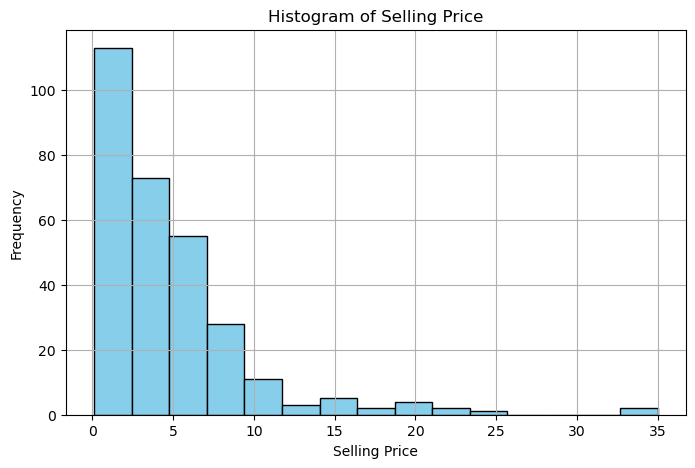

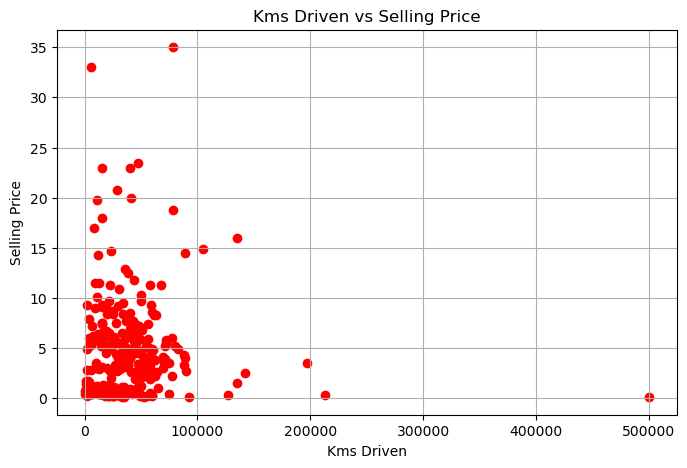

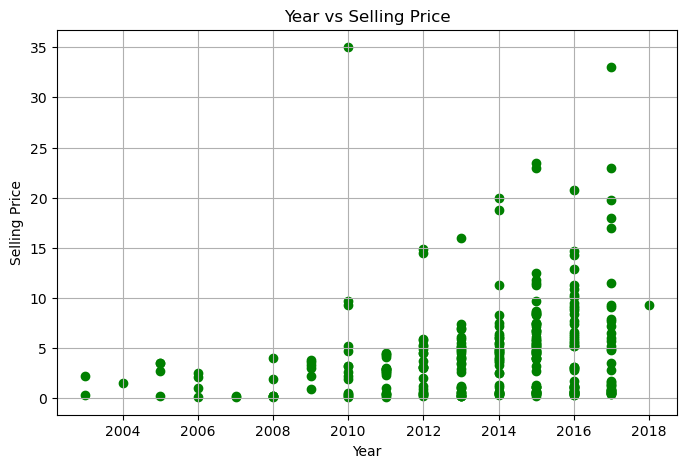

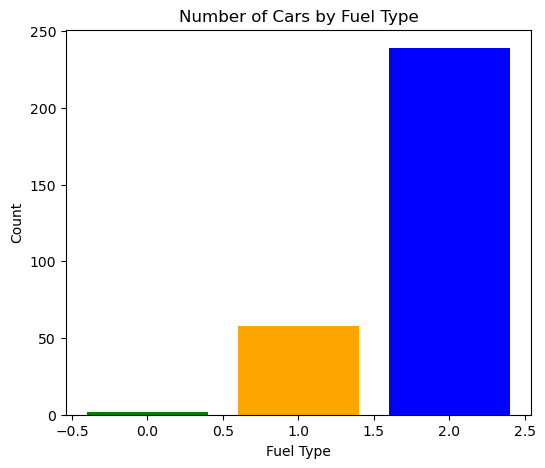

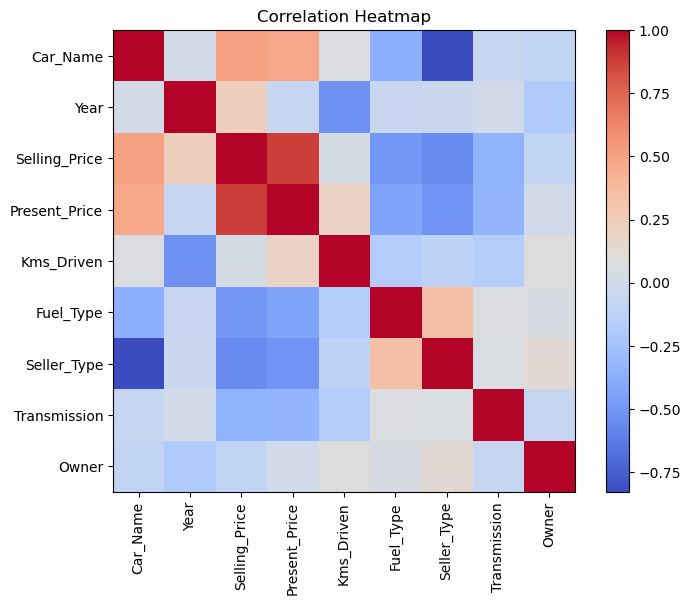

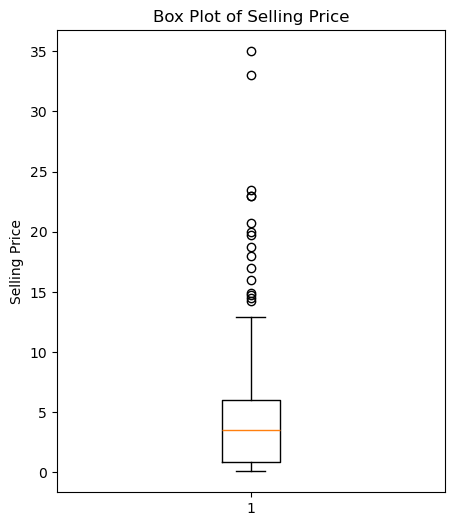

In [5]:
import matplotlib.pyplot as plt

# -----------------------------------------
# Histogram of Selling Price
# -----------------------------------------

plt.figure(figsize=(8,5))
plt.hist(df["Selling_Price"], bins=15, color="skyblue", edgecolor="black")
plt.title("Histogram of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


# -----------------------------------------
# Scatter Plot : Kms Driven vs Selling Price
# -----------------------------------------

plt.figure(figsize=(8,5))
plt.scatter(df["Kms_Driven"], df["Selling_Price"], color="red")
plt.title("Kms Driven vs Selling Price")
plt.xlabel("Kms Driven")
plt.ylabel("Selling Price")
plt.grid(True)
plt.show()


# -----------------------------------------
# Scatter Plot : Year vs Selling Price
# -----------------------------------------

plt.figure(figsize=(8,5))
plt.scatter(df["Year"], df["Selling_Price"], color="green")
plt.title("Year vs Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price")
plt.grid(True)
plt.show()


# -----------------------------------------
# Bar Chart : Fuel Types
# -----------------------------------------

fuel_counts = df["Fuel_Type"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(fuel_counts.index, fuel_counts.values, color=["blue","orange","green"])
plt.title("Number of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.show()


# -----------------------------------------
# Correlation Heatmap
# -----------------------------------------

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.show()


# -----------------------------------------
# Box Plot : Selling Price
# -----------------------------------------

plt.figure(figsize=(5,6))
plt.boxplot(df["Selling_Price"])

plt.title("Box Plot of Selling Price")
plt.ylabel("Selling Price")

plt.show()

# Task 5 : Feature Selection

In [6]:
from sklearn.model_selection import train_test_split

# -----------------------------------------
# Select Input Features (X)
# -----------------------------------------

X = df.drop("Selling_Price", axis=1)

# -----------------------------------------
# Select Target Variable (y)
# -----------------------------------------

y = df["Selling_Price"]

# -----------------------------------------
# Split Dataset into Training and Testing Sets
# -----------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# -----------------------------------------
# Display Dataset Shapes
# -----------------------------------------

print("========== Dataset Split ==========")

print("Total Features Shape :", X.shape)
print("Total Target Shape   :", y.shape)

print("\nTraining Features Shape :", X_train.shape)
print("Training Target Shape   :", y_train.shape)

print("\nTesting Features Shape  :", X_test.shape)
print("Testing Target Shape    :", y_test.shape)

print("\nDataset successfully split into 80% Training and 20% Testing.")

========== Dataset Split ==========
Total Features Shape : (299, 8)
Total Target Shape   : (299,)

Training Features Shape : (239, 8)
Training Target Shape   : (239,)

Testing Features Shape  : (60, 8)
Testing Target Shape    : (60,)

Dataset successfully split into 80% Training and 20% Testing.


# Task 6 : Build a Linear Regression Model

In [7]:
from sklearn.linear_model import LinearRegression

# -----------------------------------------
# Create Linear Regression Model
# -----------------------------------------

model = LinearRegression()

# -----------------------------------------
# Train the Model
# -----------------------------------------

model.fit(X_train, y_train)

print("Model trained successfully.")

# -----------------------------------------
# Make Predictions on Test Data
# -----------------------------------------

y_pred = model.predict(X_test)

print("\n========== Predicted Selling Prices ==========")
print(y_pred)

# -----------------------------------------
# Compare Actual vs Predicted Values
# -----------------------------------------

print("\n========== Actual vs Predicted ==========")

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(comparison.head(10))

Model trained successfully.

========== Predicted Selling Prices ==========
[ 7.50312945  7.5393869   1.31974879  6.76386908 11.2251942   4.49174464
  8.54823629  1.78979001  8.71953242 -1.00564316 10.11953537 -1.00530497
  0.78498788  1.6759579   5.14216484  5.10006531  1.22334036  1.90620282
 21.47742416  1.01313695  1.08521483  2.61174978  5.65828971  0.30819574
  6.03524577  7.83247601  8.47048855  1.25976964  4.94829184  5.06761792
  6.48148313  5.7678287   6.04252522  2.79998426  3.01884856  6.83398202
  1.33909705 -4.65473967  1.47883508 10.42991807  7.16115166  8.90161651
  1.54585334  4.01945692  1.11234386 -2.21107076  8.18486793  4.31439384
  5.70888157 -0.6377246   0.57746933  0.11458829 10.8810566   9.25216276
  7.31663423  6.09268343  3.75488401  3.54906658  9.37168151  9.19149654]

========== Actual vs Predicted ==========
   Actual Price  Predicted Price
0          8.99         7.503129
1          8.35         7.539387
2          0.45         1.319749
3          7.45   

# Task 7 : Model Evaluation

In [8]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# -----------------------------------------
# Calculate Evaluation Metrics
# -----------------------------------------

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

# -----------------------------------------
# Display Results
# -----------------------------------------

print("========== Model Evaluation ==========\n")

print("Mean Absolute Error (MAE) :", mae)

print("Mean Squared Error (MSE) :", mse)

print("Root Mean Squared Error (RMSE) :", rmse)

print("R² Score :", r2)

# -----------------------------------------
# Interpretation
# -----------------------------------------

print("\n========== Interpretation ==========\n")

print("1. MAE tells the average prediction error.")

print("2. MSE gives more importance to large errors.")

print("3. RMSE represents prediction error in the same unit as Selling Price.")

print("4. R² Score tells how well the model predicts the data.")

if r2 >= 0.90:
    print("\nExcellent Model Performance")

elif r2 >= 0.75:
    print("\nVery Good Model Performance")

elif r2 >= 0.50:
    print("\nAverage Model Performance")

else:
    print("\nPoor Model Performance")

========== Model Evaluation ==========

Mean Absolute Error (MAE) : 1.571163685627759
Mean Squared Error (MSE) : 6.823318913691078
Root Mean Squared Error (RMSE) : 2.612148333018452
R² Score : 0.7352559076589119

========== Interpretation ==========

1. MAE tells the average prediction error.
2. MSE gives more importance to large errors.
3. RMSE represents prediction error in the same unit as Selling Price.
4. R² Score tells how well the model predicts the data.

Average Model Performance


# Task 8 : Prediction

In [9]:
# -----------------------------------------
# Select One Sample Car
# -----------------------------------------

sample_car = X.iloc[[0]]

print("========== Sample Car Details ==========\n")
print(sample_car)

# -----------------------------------------
# Predict Selling Price
# -----------------------------------------

predicted_price = model.predict(sample_car)

print("\n========== Prediction ==========\n")

print("Predicted Selling Price :", predicted_price[0])

# -----------------------------------------
# Compare with Actual Price
# -----------------------------------------

actual_price = y.iloc[0]

print("Actual Selling Price    :", actual_price)

# -----------------------------------------
# Prediction Summary
# -----------------------------------------

print("\n========== Prediction Summary ==========\n")

print("The trained Linear Regression model successfully predicted the selling price of the selected car.")

========== Sample Car Details ==========

   Car_Name  Year  Present_Price  Kms_Driven  Fuel_Type  Seller_Type  \
0        90  2014           5.59       27000          2            0   

   Transmission  Owner  
0             1      0  

========== Prediction ==========

Predicted Selling Price : 4.022193332169763
Actual Selling Price    : 3.35

========== Prediction Summary ==========

The trained Linear Regression model successfully predicted the selling price of the selected car.
